In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Question 2.2 Answer

# Creating pareto distribution
pareto = np.random.pareto(a = 2, size = 10000)

# List of Sample Sizes
full_size = [10, 50, 100, 250, 500, 1000, 2500, 5000, 10000]

# Loop for bootstrapping, starts by looping through sample size list
for i in full_size:
    
    sample_means = []

    # Bootstrapping list that will create random samples and take the mean of it, loops 1000 times
    for x in range(1000):

        # Create random sample from pareto distribution based on the sample size stored in i
        sample = np.random.choice(pareto, size = i)

        # Append mean of sample to sample means list
        sample_means.append(np.mean(sample))

    # Take the variance of the sample means list
    variance = np.var(sample_means)

    # Display the sample variance for the sample size
    print(f"The sample variance for sample size {i} is {variance :.4f}.")



The sample variance for sample size 10 is 0.6035.
The sample variance for sample size 50 is 0.1164.
The sample variance for sample size 100 is 0.0580.
The sample variance for sample size 250 is 0.0232.
The sample variance for sample size 500 is 0.0119.
The sample variance for sample size 1000 is 0.0060.
The sample variance for sample size 2500 is 0.0024.
The sample variance for sample size 5000 is 0.0011.
The sample variance for sample size 10000 is 0.0006.


In [ ]:
# Question 4.1 Answer

data1 = pd.read_csv('homework_4.1.csv')

# Splitting W variable into bins
data1['w_range'] = pd.cut(data1['W'], bins = 10)

effects = []

# Looping through groups based on the W bin
for w_range, group in data1.groupby('w_range', observed = True):

    # Calculating Y mean
    y_mean1 = group.loc[group['Z'] == 1, 'Y'].mean()
    y_mean0 = group.loc[group['Z'] == 0, 'Y'].mean()

    # Calculating X mean
    x_mean1 = group.loc[group['Z'] == 1, 'X'].mean()
    x_mean0 = group.loc[group['Z'] == 0, 'X'].mean()

    # Calculating y and x difference
    y_diff = y_mean1 - y_mean0
    x_diff = x_mean1 - x_mean0

    # Checking to ensure x and y are not NA and X is not 0
    if x_diff != 0 and pd.notna(x_diff) and pd.notna(y_diff): 

        # Calculating effect
        effect = y_diff/x_diff

        effects.append(effect)

# Calculating overall effect
overall_effect = np.mean(effects)

print(f"The overall mean for the second task is {overall_effect :.2f}.")

The overall mean for the second task is 0.91.


In [4]:
# Question 4.2 Answer

data2 = pd.read_csv('homework_4.2.a.csv')
data3 = pd.read_csv('homework_4.2.b.csv')

display(data2.head())
display(data3.head())

,X,Y
0,81.822339,1
1,92.487870,0
2,85.372460,0
3,78.828025,0
4,75.807080,1


,X2,Y2
0,76.643034,1
1,87.743397,1
2,81.639469,1
3,73.740485,0
4,90.480268,1


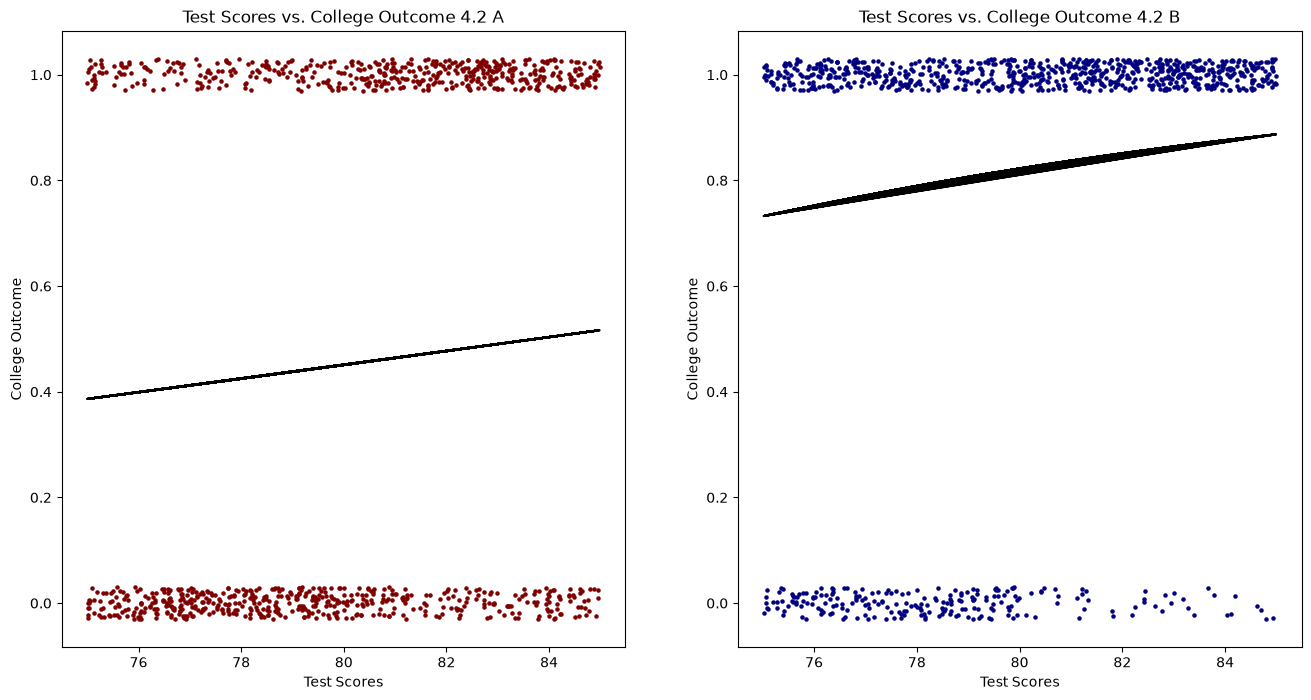

In [ ]:
from sklearn.linear_model import LogisticRegression

# Constructing and fitting models
model1 = LogisticRegression()
model1.fit(data2[['X']], data2['Y'])

model2 = LogisticRegression()
model2.fit(data3[['X2']], data3['Y2'])

# Only getting data that has test scores between 75 and 85
data2_plot = data2[(data2['X'] >= 75) & (data2['X'] <= 85)].copy()
data3_plot = data3[(data3['X2'] >= 75) & (data3['X2'] <= 85)].copy()

# Randomly sampling 1000 points so charts can be interpretted
data2_plot = data2_plot.sample(n = 1000, random_state = 42)
data3_plot = data3_plot.sample(n = 1000, random_state = 42)

# Constructing a jitter so the y points are not stacked on top of each other
y_jitter1 = data2_plot['Y'] + np.random.uniform(-0.03, 0.03, len(data2_plot))
y_jitter2 = data3_plot['Y2'] + np.random.uniform(-0.03, 0.03, len(data3_plot))

# Getting probabilities for both data
y_probs1 = model1.predict_proba(data2_plot[['X']])[:, 1]
y_probs2 = model2.predict_proba(data3_plot[['X2']])[:, 1]

# Plotting the scatter plots with the line of y probabilities
fig, ax = plt.subplots(1, 2, figsize = (16, 8))

ax[0].scatter(data2_plot['X'], y_jitter1, s = 5, color = 'maroon')
ax[0].plot(data2_plot['X'], y_probs1, color = 'black')
ax[0].set_title('Test Scores vs. College Outcome 4.2 A')
ax[0].set_xlabel('Test Scores')
ax[0].set_ylabel('College Outcome')

ax[1].scatter(data3_plot['X2'], y_jitter2, s = 5, color = 'navy')
ax[1].plot(data3_plot['X2'], y_probs2, color = 'black')
ax[1].set_title('Test Scores vs. College Outcome 4.2 B')
ax[1].set_xlabel('Test Scores')
ax[1].set_ylabel('College Outcome')

plt.show()